II. Programming and critical analysis

Use the Breast_cancer_dataset.csv dataset available at the course’s webpage and, using sklearn, apply a 5-fold stratified cross-validation with shuffling for the assessment of predictive models along this section.

1)​ Compare the performance of a 𝑘𝑁𝑁 with 𝑘 = 5 and a Naïve Bayes with Gaussian assumption:

a.​ [1.0v] Compute the accuracies for each classifier. Which is more stable than the other regarding performance, and why?

In [4]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import pandas as pd
import numpy as np

# Carregar e limpar dataset
df = pd.read_csv('Breast_cancer_dataset.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Separar features e target
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis']

# Inicializar modelos
knn = KNeighborsClassifier(n_neighbors=5)
gnb = GaussianNB()

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
knn_scores = cross_val_score(knn, X, y, cv=cv, scoring='accuracy')
gnb_scores = cross_val_score(gnb, X, y, cv=cv, scoring='accuracy')

# Resultados
print("kNN (k=5) scores:", knn_scores)
print(f"kNN Mean: {knn_scores.mean():.4f}, Std: {knn_scores.std():.4f}")

print("\nNaive Bayes scores:", gnb_scores)
print(f"Naive Bayes Mean: {gnb_scores.mean():.4f}, Std: {gnb_scores.std():.4f}")

kNN (k=5) scores: [0.92105263 0.93859649 0.92105263 0.9122807  0.96460177]
kNN Mean: 0.9315, Std: 0.0186

Naive Bayes scores: [0.92105263 0.96491228 0.9122807  0.93859649 0.95575221]
Naive Bayes Mean: 0.9385, Std: 0.0199


Uma vez que o desvio padrão do k-Nearest Neighbors é ligeiramente menor, podemos afirmar que este classificador é mais estável. 

Isto deve-se, provavelmente, ao facto de existirem features correlacionadas no dataset (por exemplo, radius_mean e area_mean), que são melhor tratadas pelo kNN, que as interpreta como pontos no espaço a fim de procurar casos similares numa vizinhança, do que pelo Gaussian Naive Bayes, que assume sempre independência entre features e que acaba, assim, por desenhar novas suposições probabilísticas a partir de informação que, na realidade, está correlacionada com uma outra qualquer feature.

b.​ [1.0v] Provide the accuracy of the kNN model, this time preprocessing the data with a Min-Max scaler before training the model. Explain the impact that this step has on the performance of the model, providing an explanation for the results.

In [9]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

# Pipeline com scaler para kNN
knn_scaled = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# Cross-validation com kNN escalado
knn_scaled_scores = cross_val_score(knn_scaled, X, y, cv=cv, scoring='accuracy')

# Resultados
print("\nkNN Scaled (k=5) scores:", knn_scaled_scores)
print(f"kNN Scaled Mean: {knn_scaled_scores.mean():.4f}, Std: {knn_scaled_scores.std():.4f}")

print(f"\nComparação:")
print(f"kNN sem scaling: {knn_scores.mean():.4f}")
print(f"kNN com scaling: {knn_scaled_scores.mean():.4f}")
print(f"Diferença: {(knn_scaled_scores.mean() - knn_scores.mean()):.4f}")


kNN Scaled (k=5) scores: [0.93859649 0.99122807 0.97368421 0.97368421 0.98230088]
kNN Scaled Mean: 0.9719, Std: 0.0179

Comparação:
kNN sem scaling: 0.9315
kNN com scaling: 0.9719
Diferença: 0.0404


Dado que o classificador kNN depende da distância entre os datapoints para realizar a classificação, variáveis com maiores amplitudes podem influenciar desproporcionalmente os cálculos de distância, gerando classificações enviesadas.

Através do escalonamento Min-Max, que transforma todas as variáveis para uma escala comum, é possível eliminar este enviesamento e, assim, consegue-se obter um modelo de melhor desempenho, mais fiável e mais estável, conforme podemos ver pelos resultados obtidos: não só a accuracy média é maior, como o desvio padrão entre as accuracies é menor.  

c.​ [1.0v] Using scipy, determine whether the scaled 𝑘𝑁𝑁 model is statistically superior to Naïve Bayes (also scaled) when it comes to accuracy, and justify your result.

In [11]:
from scipy.stats import ttest_rel

# Naive Bayes também com scaling (para comparação justa)
gnb_scaled = Pipeline([
    ('scaler', MinMaxScaler()),
    ('gnb', GaussianNB())
])

gnb_scaled_scores = cross_val_score(gnb_scaled, X, y, cv=cv, scoring='accuracy')

# Paired t-test
statistic, p_value = ttest_rel(knn_scaled_scores, gnb_scaled_scores)

print("\nPaired t-test:")
print(f"kNN (scaled) scores: {knn_scaled_scores}")
print(f"GNB (scaled) scores: {gnb_scaled_scores}")
print(f"t-statistic: {statistic:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Alpha: 0.05")

if p_value < 0.05:
    if knn_scaled_scores.mean() > gnb_scaled_scores.mean():
        print(f"\nConclusão: kNN é estatisticamente superior (p={p_value:.4f} < 0.05)")
    else:
        print(f"\nConclusão: Naive Bayes é estatisticamente superior (p={p_value:.4f} < 0.05)")
else:
    print(f"\nConclusão: Não há diferença estatisticamente significativa (p={p_value:.4f} >= 0.05)")


Paired t-test:
kNN (scaled) scores: [0.93859649 0.99122807 0.97368421 0.97368421 0.98230088]
GNB (scaled) scores: [0.9122807  0.93859649 0.92105263 0.94736842 0.92920354]
t-statistic: 6.5075
P-value: 0.0029
Alpha: 0.05

Conclusão: kNN é estatisticamente superior (p=0.0029 < 0.05)


A fim de testar a hipótese de que o classificador kNN é estatisticamente superior ao Naive Bayes, foi realizado um paired t-test, partindo das seguintes hipóteses:

- Hipótese nula (H<sub>0</sub>): A precisão do kNN não é diferente da do Naive Bayes;
- Hipótese alternativa (H<sub>1</sub>): A precisão do kNN é diferente da do Naive Bayes.

Analisando os resultados acima, é possível verificar que o p-value obtido é inferior a 0.05, indicando-nos que a probabilidade das diferenças de performance verificadas entre os dois classificadores terem ocorrido como fruto do acaso é inferior a 5%, demonstrando, assim, que os resultados são estatisticamente significativos e que, portanto, é possível confirmar que o modelo kNN é superior ao Naive Bayes. 

2)​ Using a 70-30 train-test split, vary the number of neighbors of a 𝑘𝑁𝑁 classifier using 𝑘 = {1, 5, 10, 15, 20, 25}. Additionally, for each 𝑘, train one classifier using uniform weights and distance weights.

a.​ [1.0v] Plot the train and test accuracies for each model.

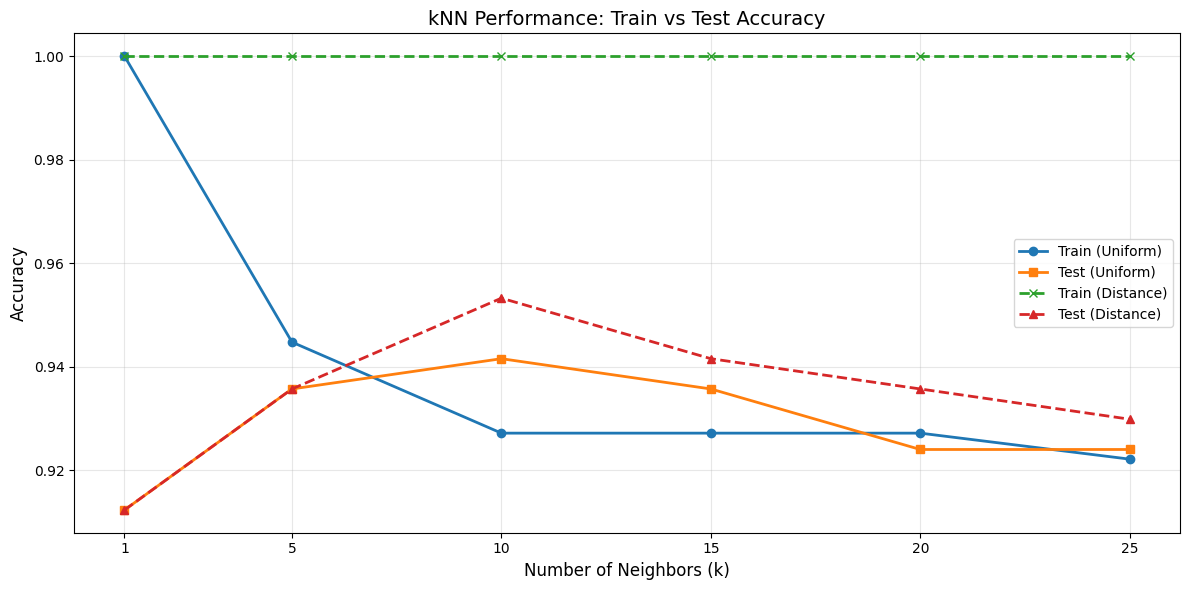

k	Train_Uni	Test_Uni	Train_Dist	Test_Dist
1	1.0000		0.9123		1.0000		0.9123
5	0.9447		0.9357		1.0000		0.9357
10	0.9271		0.9415		1.0000		0.9532
15	0.9271		0.9357		1.0000		0.9415
20	0.9271		0.9240		1.0000		0.9357
25	0.9221		0.9240		1.0000		0.9298


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# Carregar e limpar dataset
df = pd.read_csv('Breast_cancer_dataset.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Features e target
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis']

# 70-30 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

# Valores de k
k_values = [1, 5, 10, 15, 20, 25]

# Listas para armazenar accuracies
train_acc_uniform = []
test_acc_uniform = []
train_acc_distance = []
test_acc_distance = []

# Iterar sobre diferentes valores de k
for k in k_values:
    # kNN com uniform weights
    knn_uniform = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    knn_uniform.fit(X_train, y_train)
    train_acc_uniform.append(knn_uniform.score(X_train, y_train))
    test_acc_uniform.append(knn_uniform.score(X_test, y_test))
    
    # kNN com distance weights
    knn_distance = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_distance.fit(X_train, y_train)
    train_acc_distance.append(knn_distance.score(X_train, y_train))
    test_acc_distance.append(knn_distance.score(X_test, y_test))

# Plot
plt.figure(figsize=(12, 6))

plt.plot(k_values, train_acc_uniform, 'o-', label='Train (Uniform)', linewidth=2)
plt.plot(k_values, test_acc_uniform, 's-', label='Test (Uniform)', linewidth=2)
plt.plot(k_values, train_acc_distance, 'x--', label='Train (Distance)', linewidth=2)
plt.plot(k_values, test_acc_distance, '^--', label='Test (Distance)', linewidth=2)

plt.xlabel('Number of Neighbors (k)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('kNN Performance: Train vs Test Accuracy', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

# Print resultados para análise
print("k\tTrain_Uni\tTest_Uni\tTrain_Dist\tTest_Dist")
for i, k in enumerate(k_values):
    print(f"{k}\t{train_acc_uniform[i]:.4f}\t\t{test_acc_uniform[i]:.4f}\t\t{train_acc_distance[i]:.4f}\t\t{test_acc_distance[i]:.4f}")

b.​ [1.5v] Explain the impact of increasing the number of neighbors on the generalization ability of the models. Elaborate on the trade-offs between small and large values of k and suggest its optimal value.

A partir da análise do plot acima, é possível verificar que, até certo ponto, o aumento do valor de k leva a uma melhor capacidade de generalização dos modelos, degenerando, depois.

O uso de valores de k muito pequenos, como 1 ou 2, aparenta causar overfitting, capturando-se particularidades dos dados de treino, como o seu ruído e a presença de outliers e obtendo-se, consequentemente, accuracies menores, quando comparado a valores de k entre a faixa dos 5 e os 20. Aqui verificam-se as melhores accuracies do modelo: valores superiores a 20 parecem levar a underfitting, conseguindo-se accuracies cada vez menores à medida que se aumenta o valor de k, uma vez que se perdem padrões importantes, já que o cálculo da média dos vários datapoints passa a acontecer numa bola demasiado grande do espaço.

3)​ [1.5v] Suppose you must deploy either kNN or Naïve Bayes in a clinical setting for breast cancer diagnosis. Discuss at least two factors that would influence your choice,
referencing insights from your experiments. Comment on the models’ performance with medical datasets and the overall models’ characteristics from a more technical context (e.g., interpretability, computational cost, or scalability).

Note: Use all optional parameters as default or justify any changes in your answers.

Tendo em conta o dataset em questão e os testes sobre ele realizados ao longo deste Homework, é possível referir alguns fatores que poderiam influenciar a escolha de um dos modelos estudados - kNN ou Naive Bayes - em detrimento do outro.

Por um lado, uma vez que as features do dataset estão correlacionadas, é possível inferir que o kNN possa ser uma melhor escolha, já que estas correlações violariam a presunção de independência entre features subjacente ao Naive Bayes, levando, assim, a uma redução na estabilidade deste modelo (como, de resto, se verificou em 1.a)).

Por outro, dado que o classificador Naive Bayes produz afirmações probabilísticas como output, tem-se, com ele, uma maior interpretabilidade do que com o kNN. Embora a proximidade de um caso com outros seja passível de ser discutida num contexto clínico, a transparência dada por um modelo probabilístico como o conseguido em Naive Bayes poderá ser de valor num context clínico.

Estes fatores, entre outros como o maior custo computacional de kNN face a Naive Bayes, poderão ser determinantes na escolha de um classificador ou de outro. 